In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
MCC_FILE = PROJECT_ROOT / "data" / "raw" / "mcc_codes.json"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError("Run src/01_process_data.py before this EDA notebook.")

transactions = pd.read_csv(DATA_FILE)
transactions.shape

(8914963, 12)

## Prepare EDA Columns


In [2]:
transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
transactions["amount_value"] = pd.to_numeric(
    transactions["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
transactions["hour"] = transactions["date"].dt.hour
transactions["day_name"] = transactions["date"].dt.day_name()
transactions["month"] = transactions["date"].dt.to_period("M").astype(str)

transactions[["date", "amount", "amount_value", "hour", "day_name", "is_fraud"]].head()

,date,amount,amount_value,hour,day_name,is_fraud
0,2010-01-01 00:01:00,-77.00,-77.00,0,Friday,0
1,2010-01-01 00:02:00,14.57,14.57,0,Friday,0
2,2010-01-01 00:02:00,80.00,80.00,0,Friday,0
3,2010-01-01 00:06:00,46.41,46.41,0,Friday,0
4,2010-01-01 00:07:00,4.81,4.81,0,Friday,0


## Dataset Overview

In [3]:
overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns before EDA features",
            "date start",
            "date end",
            "unique clients",
            "unique cards",
            "unique merchants",
            "fraud transactions",
            "fraud rate (%)",
        ],
        "value": [
            f"{len(transactions):,}",
            transactions.drop(columns=["amount_value", "hour", "day_name", "month"]).shape[1],
            transactions["date"].min(),
            transactions["date"].max(),
            f"{transactions['client_id'].nunique():,}",
            f"{transactions['card_id'].nunique():,}",
            f"{transactions['merchant_id'].nunique():,}",
            f"{int(transactions['is_fraud'].sum()):,}",
            round(transactions["is_fraud"].mean() * 100, 4),
        ],
    }
)
overview

,metric,value
0,rows,"8,914,963"
1,columns before EDA features,12
2,date start,2010-01-01 00:01:00
3,date end,2019-10-31 23:57:00
4,unique clients,"1,219"
5,unique cards,"4,070"
6,unique merchants,"66,537"
7,fraud transactions,"13,332"
8,fraud rate (%),0.1495


In [4]:
attribute_types = pd.DataFrame(
    {
        "attribute": [
            "id", "date", "client_id", "card_id", "amount", "use_chip",
            "merchant_id", "merchant_city", "merchant_state", "mcc", "errors", "is_fraud"
        ],
        "EDA type": [
            "identifier", "datetime", "identifier", "identifier", "numerical after parsing", "categorical",
            "identifier", "categorical", "categorical", "categorical code", "error flag/text", "binary target"
        ],
        "use in analysis": [
            "merge key only", "time patterns and features", "customer grouping", "card grouping", "amount distribution", "payment method pattern",
            "merchant grouping", "location pattern", "location pattern", "merchant category pattern", "transaction issue pattern", "fraud label"
        ],
    }
)
attribute_types

,attribute,EDA type,use in analysis
0,id,identifier,merge key only
1,date,datetime,time patterns and features
2,client_id,identifier,customer grouping
3,card_id,identifier,card grouping
4,amount,numerical after parsing,amount distribution
5,use_chip,categorical,payment method pattern
6,merchant_id,identifier,merchant grouping
7,merchant_city,categorical,location pattern
8,merchant_state,categorical,location pattern
9,mcc,categorical code,merchant category pattern


## Data Quality After Processing

In [5]:
missing_summary = (
    transactions.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda table: (table["missing_count"] / len(transactions) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)
missing_summary

,missing_count,missing_percent
errors,8773196,98.41
merchant_state,1047865,11.75
id,0,0.00
date,0,0.00
amount,0,0.00
use_chip,0,0.00
client_id,0,0.00
card_id,0,0.00
merchant_city,0,0.00
merchant_id,0,0.00


In [6]:
transactions["amount_value"] = pd.to_numeric(
    transactions["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce"
)

transactions["abs_amount"] = transactions["amount_value"].abs()

transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
transactions["hour"] = transactions["date"].dt.hour
transactions["day_name"] = transactions["date"].dt.day_name()
transactions["month"] = transactions["date"].dt.to_period("M").astype(str)

transactions["has_error"] = transactions["errors"].notna().astype(int)

feature_preview = transactions[
    ["amount", "amount_value", "abs_amount", "date", "hour", "day_name", "month", "errors", "has_error", "is_fraud"]
].head(10)

feature_preview

,amount,amount_value,abs_amount,date,hour,day_name,month,errors,has_error,is_fraud
0,-77.00,-77.00,77.00,2010-01-01 00:01:00,0,Friday,2010-01,NaN,0,0
1,14.57,14.57,14.57,2010-01-01 00:02:00,0,Friday,2010-01,NaN,0,0
2,80.00,80.00,80.00,2010-01-01 00:02:00,0,Friday,2010-01,NaN,0,0
3,46.41,46.41,46.41,2010-01-01 00:06:00,0,Friday,2010-01,NaN,0,0
4,4.81,4.81,4.81,2010-01-01 00:07:00,0,Friday,2010-01,NaN,0,0
5,26.46,26.46,26.46,2010-01-01 00:14:00,0,Friday,2010-01,NaN,0,0
6,3.51,3.51,3.51,2010-01-01 00:23:00,0,Friday,2010-01,NaN,0,0
7,2.58,2.58,2.58,2010-01-01 00:23:00,0,Friday,2010-01,NaN,0,0
8,39.63,39.63,39.63,2010-01-01 00:26:00,0,Friday,2010-01,NaN,0,0
9,43.33,43.33,43.33,2010-01-01 00:27:00,0,Friday,2010-01,NaN,0,0


In [7]:
# Final Processed Dataset Export and Readiness Check

from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

final_file = processed_dir / "final_featured_transactions.csv"

transactions.to_csv(final_file, index=False)

print(f"Final processed dataset saved to: {final_file}")
print(f"Final dataset shape: {transactions.shape}")

print("\nFinal dataset columns:")
print(transactions.columns.tolist())

print("\nFraud label distribution:")
print(transactions["is_fraud"].value_counts())

transactions.head(10)

Final processed dataset saved to: data\processed\final_featured_transactions.csv
Final dataset shape: (8914963, 18)

Final dataset columns:
['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'mcc', 'errors', 'is_fraud', 'amount_value', 'hour', 'day_name', 'month', 'abs_amount', 'has_error']

Fraud label distribution:
is_fraud
0    8901631
1      13332
Name: count, dtype: int64


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,mcc,errors,is_fraud,amount_value,hour,day_name,month,abs_amount,has_error
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,5499,NaN,0,-77.00,0,Friday,2010-01,77.00,0
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,5311,NaN,0,14.57,0,Friday,2010-01,14.57,0
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,4829,NaN,0,80.00,0,Friday,2010-01,80.00,0
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,5813,NaN,0,46.41,0,Friday,2010-01,46.41,0
4,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,5942,NaN,0,4.81,0,Friday,2010-01,4.81,0
5,7475335,2010-01-01 00:14:00,1684,2140,26.46,Online Transaction,39021,ONLINE,NaN,4784,NaN,0,26.46,0,Friday,2010-01,26.46,0
6,7475338,2010-01-01 00:23:00,554,3912,3.51,Swipe Transaction,67570,Pearland,TX,5311,NaN,0,3.51,0,Friday,2010-01,3.51,0
7,7475339,2010-01-01 00:23:00,605,5061,2.58,Swipe Transaction,75781,Brooklyn,NY,5411,NaN,0,2.58,0,Friday,2010-01,2.58,0
8,7475340,2010-01-01 00:26:00,1556,2972,39.63,Swipe Transaction,59935,Beulah,ND,5499,NaN,0,39.63,0,Friday,2010-01,39.63,0
9,7475341,2010-01-01 00:27:00,1797,1127,43.33,Swipe Transaction,33326,Kahului,HI,4121,NaN,0,43.33,0,Friday,2010-01,43.33,0


In [8]:
quality_checks = pd.DataFrame(
    {
        "check": [
            "duplicate rows",
            "duplicate transaction ids",
            "invalid parsed dates",
            "invalid parsed amounts",
            "negative or reversal amounts",
        ],
        "value": [
            int(transactions.duplicated().sum()),
            int(transactions["id"].duplicated().sum()),
            int(transactions["date"].isna().sum()),
            int(transactions["amount_value"].isna().sum()),
            int((transactions["amount_value"] < 0).sum()),
        ],
    }
)
quality_checks

,check,value
0,duplicate rows,0
1,duplicate transaction ids,0
2,invalid parsed dates,0
3,invalid parsed amounts,0
4,negative or reversal amounts,442779


## Descriptive Statistics

In [9]:
transactions[["amount_value", "hour", "is_fraud"]].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).round(2)

,amount_value,hour,is_fraud
count,8914963.00,8914963.00,8914963.00
mean,42.95,12.39,0.00
std,81.53,5.09,0.04
min,-500.00,0.00,0.00
25%,8.93,9.00,0.00
50%,28.99,12.00,0.00
75%,63.68,16.00,0.00
95%,145.90,21.00,0.00
99%,315.86,23.00,0.00
max,6613.44,23.00,1.00


In [10]:
category_summary = {
    "use_chip": transactions["use_chip"].value_counts(dropna=False).head(10),
    "merchant_state": transactions["merchant_state"].value_counts(dropna=False).head(10),
    "mcc": transactions["mcc"].value_counts(dropna=False).head(10),
}
category_summary

{'use_chip': use_chip
 Swipe Transaction     4668212
 Chip Transaction      3202776
 Online Transaction    1043975
 Name: count, dtype: int64,
 'merchant_state': merchant_state
 NaN    1047865
 CA      956356
 TX      677139
 NY      574521
 FL      469600
 OH      324098
 IL      313592
 NC      286937
 PA      280037
 MI      266745
 Name: count, dtype: int64,
 'mcc': mcc
 5411    1066833
 5499     979396
 5541     955123
 5812     669808
 5912     517400
 4784     451814
 5300     403343
 4829     394401
 4121     335586
 5814     334333
 Name: count, dtype: int64}

## Fraud Distribution


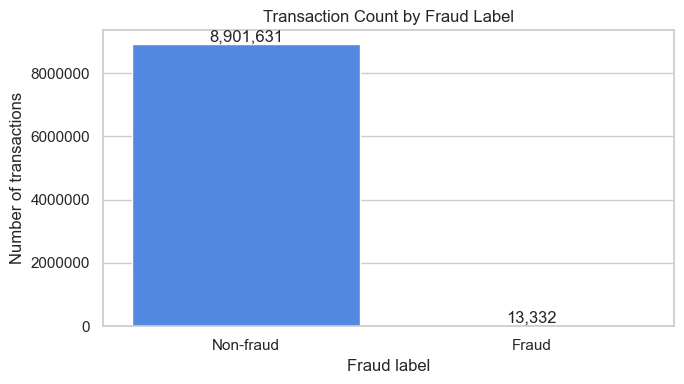

,label,transactions,percent
0,Non-fraud,8901631,99.8505
1,Fraud,13332,0.1495


In [11]:
fraud_counts = transactions["is_fraud"].value_counts().sort_index()
fraud_plot = pd.DataFrame(
    {"label": ["Non-fraud", "Fraud"], "transactions": [fraud_counts.get(0, 0), fraud_counts.get(1, 0)]}
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=fraud_plot, x="label", y="transactions", hue="label", palette=["#3b82f6", "#dc2626"], legend=False, ax=ax)
ax.set_title("Transaction Count by Fraud Label")
ax.set_xlabel("Fraud label")
ax.set_ylabel("Number of transactions")
ax.ticklabel_format(style="plain", axis="y")
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height()):,}", (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_fraud_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

fraud_plot.assign(percent=lambda table: (table["transactions"] / len(transactions) * 100).round(4))

## Transaction Amount Patterns



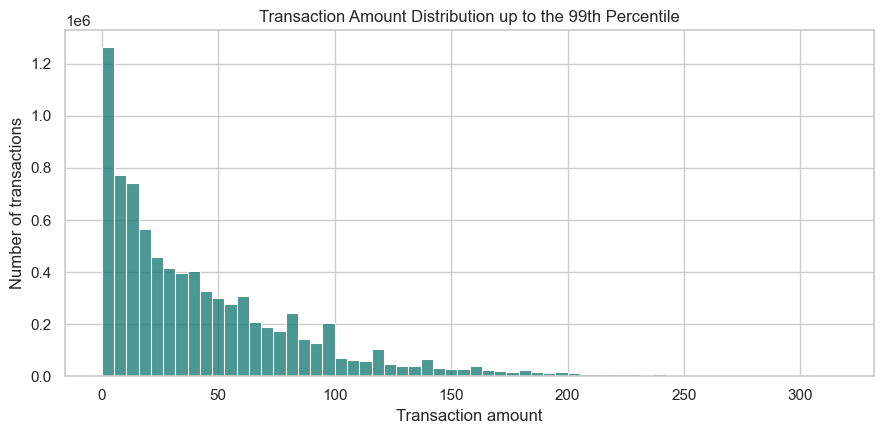

,99th percentile amount,rows shown
0,315.86,8383038


In [12]:
amount_limit = transactions["amount_value"].quantile(0.99)
amount_for_hist = transactions.loc[
    transactions["amount_value"].between(0, amount_limit, inclusive="both"),
    "amount_value",
]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(amount_for_hist, bins=60, color="#0f766e", ax=ax)
ax.set_title("Transaction Amount Distribution up to the 99th Percentile")
ax.set_xlabel("Transaction amount")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_amount_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame({"99th percentile amount": [round(amount_limit, 2)], "rows shown": [len(amount_for_hist)]})

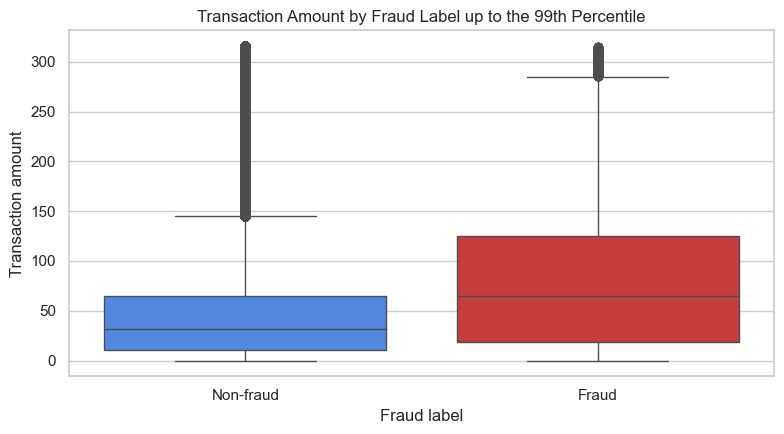

,count,mean,median,max
is_fraud,,,,
0,8901631,42.85,28.95,6613.44
1,13332,110.23,69.97,4978.45


In [13]:
amount_by_fraud = transactions.loc[
    transactions["amount_value"].between(0, amount_limit, inclusive="both"),
    ["amount_value", "is_fraud"],
].copy()
amount_by_fraud["fraud_label"] = amount_by_fraud["is_fraud"].map({0: "Non-fraud", 1: "Fraud"})

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=amount_by_fraud, x="fraud_label", y="amount_value", hue="fraud_label", palette=["#3b82f6", "#dc2626"], legend=False, ax=ax)
ax.set_title("Transaction Amount by Fraud Label up to the 99th Percentile")
ax.set_xlabel("Fraud label")
ax.set_ylabel("Transaction amount")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_amount_by_fraud.png", dpi=160, bbox_inches="tight")
plt.show()

transactions.groupby("is_fraud")["amount_value"].agg(["count", "mean", "median", "max"]).round(2)

## Fraud Rate by Transaction Amount Range


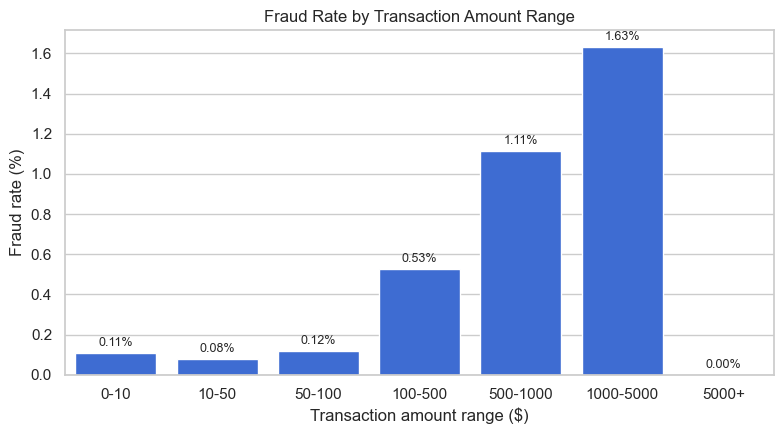

,amount_range,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
0,0-10,1955041,2130,0.001089,0.108949
1,10-50,3545633,2813,0.000793,0.079337
2,50-100,2402390,2848,0.001185,0.118549
3,100-500,983037,5188,0.005278,0.527752
4,500-1000,22733,253,0.011129,1.112920
5,1000-5000,6125,100,0.016327,1.632653
6,5000+,4,0,0.000000,0.000000


In [14]:
amount_range_data = transactions.dropna(subset=["amount_value", "is_fraud"]).copy()
amount_range_data["abs_amount"] = amount_range_data["amount_value"].abs()

amount_bins = [0, 10, 50, 100, 500, 1000, 5000, np.inf]
amount_labels = ["0-10", "10-50", "50-100", "100-500", "500-1000", "1000-5000", "5000+"]
amount_range_data["amount_range"] = pd.cut(
    amount_range_data["abs_amount"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True,
)

amount_range_summary = (
    amount_range_data.groupby("amount_range", observed=True)["is_fraud"]
    .agg(transaction_count="size", fraud_count="sum", fraud_rate="mean")
    .reset_index()
)
amount_range_summary["fraud_rate_percent"] = amount_range_summary["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=amount_range_summary, x="amount_range", y="fraud_rate_percent", color="#2563eb", ax=ax)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

ax.set_title("Fraud Rate by Transaction Amount Range")
ax.set_xlabel("Transaction amount range ($)")
ax.set_ylabel("Fraud rate (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_fraud_rate_by_amount_range.png", dpi=160, bbox_inches="tight")
plt.show()

amount_range_summary

## Monthly Fraud Trend

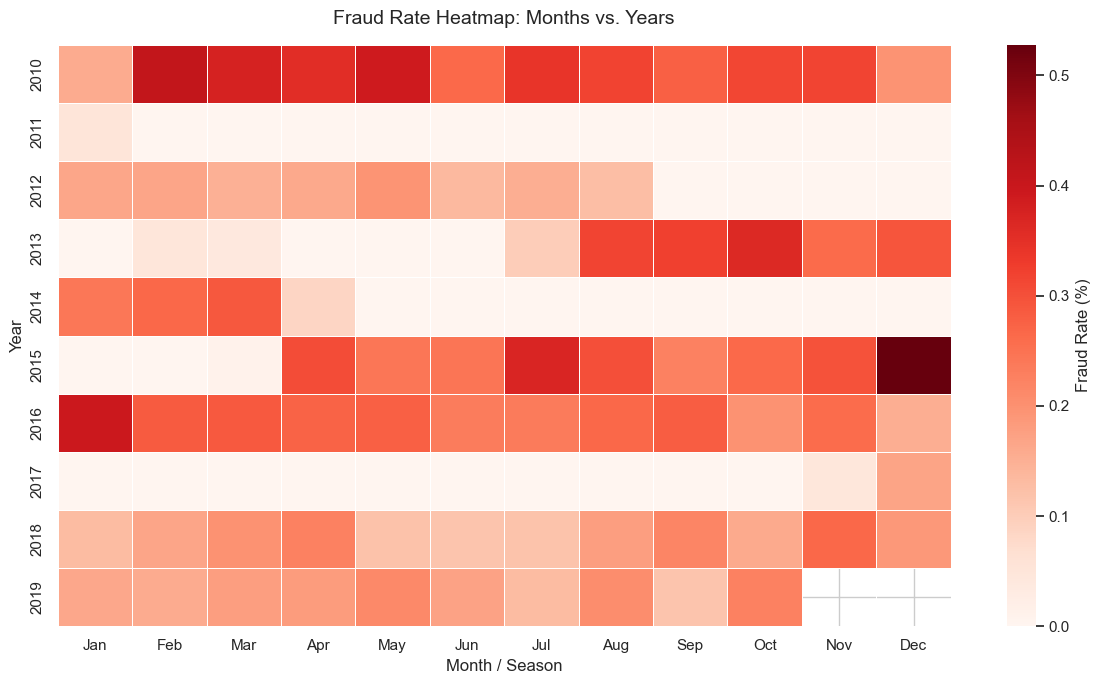

In [15]:

transactions["Year"] = transactions["date"].dt.year
transactions["Month"] = transactions["date"].dt.strftime("%b")


heatmap_data = (
    transactions.groupby(["Year", "Month"])["is_fraud"]
    .mean()
    .reset_index()
)
heatmap_data["is_fraud"] *= 100  


months_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot_df = heatmap_data.pivot(index="Year", columns="Month", values="is_fraud")
pivot_df = pivot_df[months_order]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_df, 
    cmap="Reds", 
    annot=False,          
    fmt=".2f", 
    linewidths=0.5, 
    cbar_kws={'label': 'Fraud Rate (%)'},
    ax=ax
)

ax.set_title("Fraud Rate Heatmap: Months vs. Years", fontsize=14, pad=15)
ax.set_xlabel("Month / Season", fontsize=12)
ax.set_ylabel("Year", fontsize=12)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_monthly_fraud_trend.png", dpi=160, bbox_inches="tight")
plt.show()

## Fraud Rate by Merchant State


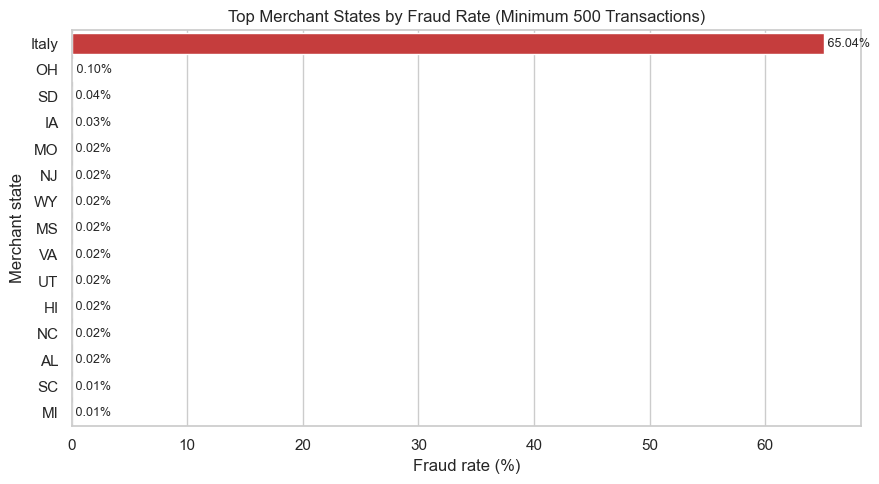

,merchant_state,transaction_count,fraud_count,fraud_rate,fraud_rate_percent
78,Italy,4706,3061,0.650446,65.044624
130,OH,324098,316,0.000975,0.097501
148,SD,20875,8,0.000383,0.038323
67,IA,107765,32,0.000297,0.029694
98,MO,131274,32,0.000244,0.024376
120,NJ,216075,42,0.000194,0.019438
195,WY,5874,1,0.000170,0.017024
99,MS,88984,15,0.000169,0.016857
186,VA,154841,26,0.000168,0.016791
180,UT,25322,4,0.000158,0.015797


In [16]:
state_fraud = (
    transactions.dropna(subset=["merchant_state"])
    .groupby("merchant_state")["is_fraud"]
    .agg(transaction_count="size", fraud_count="sum", fraud_rate="mean")
    .reset_index()
)
state_fraud = state_fraud[state_fraud["transaction_count"] >= 500].copy()
state_fraud["fraud_rate_percent"] = state_fraud["fraud_rate"] * 100
top_state_fraud = state_fraud.sort_values("fraud_rate_percent", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))

max_state_rate = top_state_fraud["fraud_rate_percent"].max()
state_colors = ["#dc2626" if x == max_state_rate else "#16a34a" for x in top_state_fraud["fraud_rate_percent"]]

sns.barplot(data=top_state_fraud, y="merchant_state", x="fraud_rate_percent", palette=state_colors, hue="merchant_state", legend=False, ax=ax)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f' {width:.2f}%', (width, p.get_y() + p.get_height() / 2.), va='center', ha='left', fontsize=9)

ax.set_title("Top Merchant States by Fraud Rate (Minimum 500 Transactions)")
ax.set_xlabel("Fraud rate (%)")
ax.set_ylabel("Merchant state")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_top_state_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

top_state_fraud


## Amount vs Hour Scatter Pattern


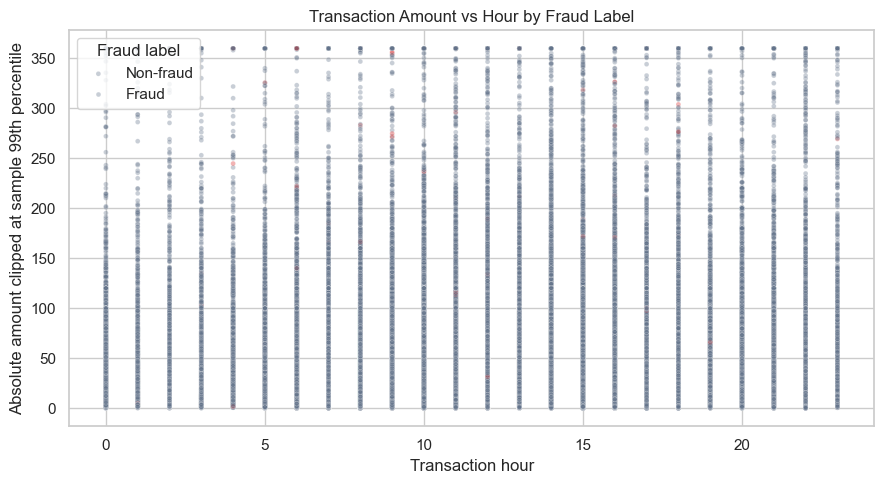

In [17]:
scatter_sample = transactions.dropna(subset=["amount_value", "hour", "is_fraud"]).sample(
    n=min(100_000, len(transactions)),
    random_state=42,
)
amount_cap = scatter_sample["amount_value"].abs().quantile(0.99)
scatter_sample = scatter_sample.assign(abs_amount_clipped=scatter_sample["amount_value"].abs().clip(upper=amount_cap))

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=scatter_sample,
    x="hour",
    y="abs_amount_clipped",
    hue="is_fraud",
    palette={0: "#64748b", 1: "#dc2626"},
    alpha=0.35,
    s=12,
    ax=ax,
)
ax.set_title("Transaction Amount vs Hour by Fraud Label")
ax.set_xlabel("Transaction hour")
ax.set_ylabel("Absolute amount clipped at sample 99th percentile")
ax.legend(title="Fraud label", labels=["Non-fraud", "Fraud"])
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_amount_vs_hour_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


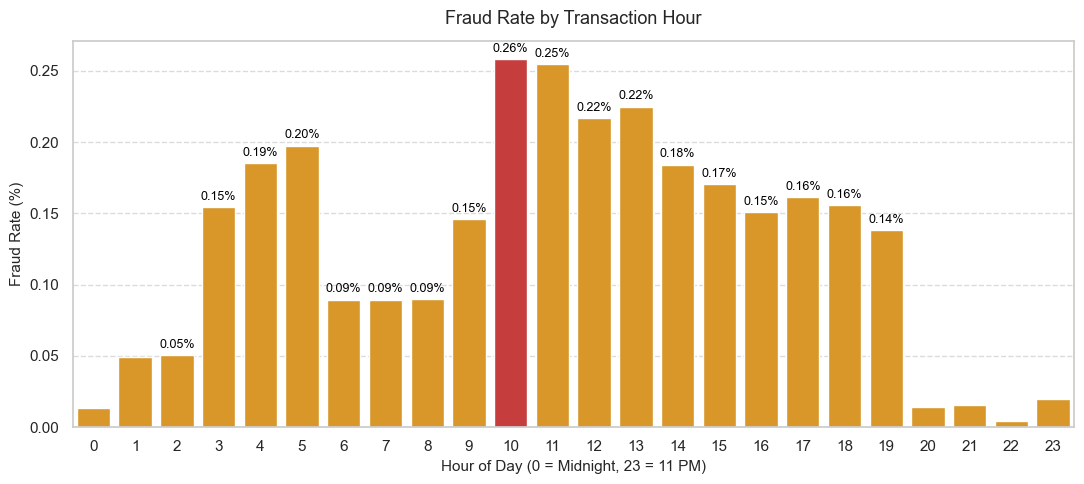

,hour,transactions,fraud_count,fraud_rate,fraud_rate_percent
0,0,94170,13,0.000138,0.013805
1,1,77322,38,0.000491,0.049145
2,2,75384,38,0.000504,0.050409
3,3,69297,107,0.001544,0.154408
4,4,77190,143,0.001853,0.185257


In [18]:
hourly_summary = transactions.groupby("hour", dropna=False).agg(
    transactions=("amount", "size"), 
    fraud_count=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean"),
).reset_index()
hourly_summary["fraud_rate_percent"] = hourly_summary["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(11, 5))

max_rate = hourly_summary["fraud_rate_percent"].max()
colors = ["#dc2626" if rate == max_rate else "#f59e0b" for rate in hourly_summary["fraud_rate_percent"]]

sns.barplot(
    data=hourly_summary, 
    x="hour", 
    y="fraud_rate_percent", 
    palette=colors, 
    hue="hour",          
    legend=False,
    ax=ax
)

ax.set_xticks(range(0, 24))
ax.set_xticklabels(range(0, 24))

ax.set_title("Fraud Rate by Transaction Hour", fontsize=13, pad=12)
ax.set_xlabel("Hour of Day (0 = Midnight, 23 = 11 PM)", fontsize=11)
ax.set_ylabel("Fraud Rate (%)", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0.05: 
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black',
                    xytext=(0, 3), textcoords='offset points')

fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_fraud_rate_by_hour.png", dpi=160, bbox_inches="tight")
plt.show()

hourly_summary.head()

## Payment Method and Merchant Category Patterns

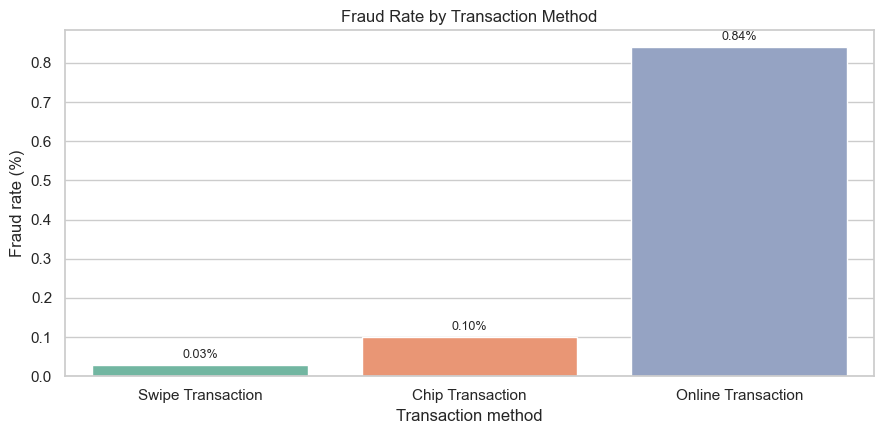

,use_chip,transactions,fraud_count,fraud_rate,fraud_rate_percent
0,Swipe Transaction,4668212,1377,0.0003,0.0295
1,Chip Transaction,3202776,3176,0.0010,0.0992
2,Online Transaction,1043975,8779,0.0084,0.8409


In [20]:
chip_summary = transactions.groupby("use_chip", dropna=False).agg(
    transactions=("amount", "size"),
    fraud_count=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean"),
).sort_values("transactions", ascending=False).reset_index()
chip_summary["fraud_rate_percent"] = chip_summary["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.barplot(data=chip_summary, x="use_chip", y="fraud_rate_percent", hue="use_chip", palette="Set2", legend=False, ax=ax)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

ax.set_title("Fraud Rate by Transaction Method")
ax.set_xlabel("Transaction method")
ax.set_ylabel("Fraud rate (%)")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_fraud_rate_by_transaction_method.png", dpi=160, bbox_inches="tight")
plt.show()

chip_summary.round(4)

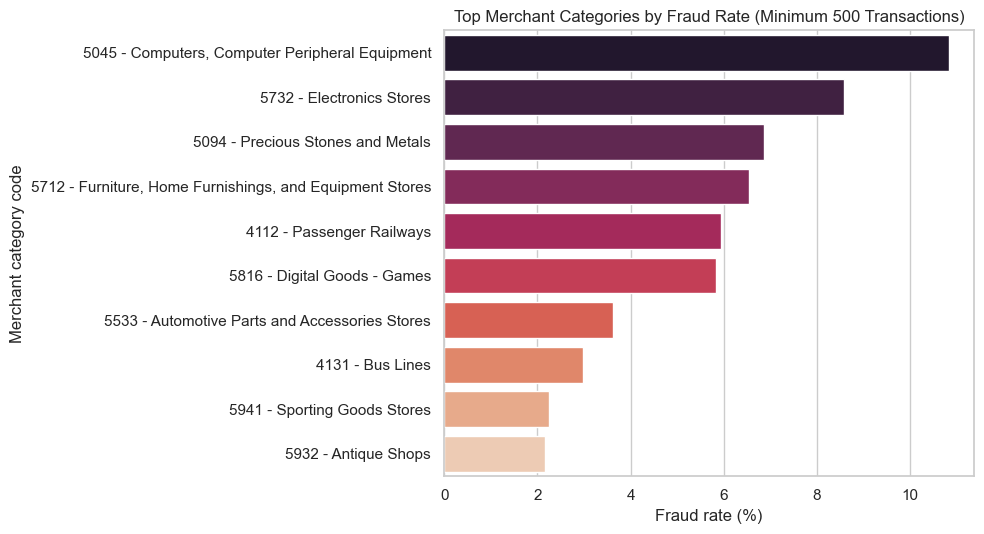

,mcc,mcc_name,transactions,fraud_count,fraud_rate_percent
46,5045,"Computers, Computer Peripheral Equipment",1883,204,10.8338
67,5732,Electronics Stores,4689,402,8.5733
47,5094,Precious Stones and Metals,3525,242,6.8652
64,5712,"Furniture, Home Furnishings, and Equipment Stores",2600,170,6.5385
34,4112,Passenger Railways,1463,87,5.9467
73,5816,Digital Goods - Games,1866,109,5.8414
58,5533,Automotive Parts and Accessories Stores,802,29,3.6160
36,4131,Bus Lines,1506,45,2.9880
77,5941,Sporting Goods Stores,755,17,2.2517
76,5932,Antique Shops,3977,86,2.1624


In [ ]:
mcc_summary = transactions.groupby("mcc", dropna=False).agg(
    transactions=("id", "size"),
    fraud_count=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean"),
).reset_index()
mcc_summary = mcc_summary[mcc_summary["transactions"] >= 500].copy()
mcc_summary["fraud_rate_percent"] = mcc_summary["fraud_rate"] * 100

if MCC_FILE.exists():
    with MCC_FILE.open() as handle:
        mcc_names = json.load(handle)
    mcc_summary["mcc_name"] = mcc_summary["mcc"].astype(str).map(mcc_names)
else:
    mcc_summary["mcc_name"] = pd.NA

top_mcc = mcc_summary.sort_values("fraud_rate_percent", ascending=False).head(10).copy()
top_mcc["mcc_label"] = top_mcc["mcc"].astype(str) + " - " + top_mcc["mcc_name"].fillna("Unknown")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=top_mcc, y="mcc_label", x="fraud_rate_percent", hue="mcc_label", palette="rocket", legend=False, ax=ax)
ax.set_title("Top Merchant Categories by Fraud Rate (Minimum 500 Transactions)")
ax.set_xlabel("Fraud rate (%)")
ax.set_ylabel("Merchant category code")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_top_mcc_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

top_mcc[["mcc", "mcc_name", "transactions", "fraud_count", "fraud_rate_percent"]].round(4)

## Numeric Correlation Check


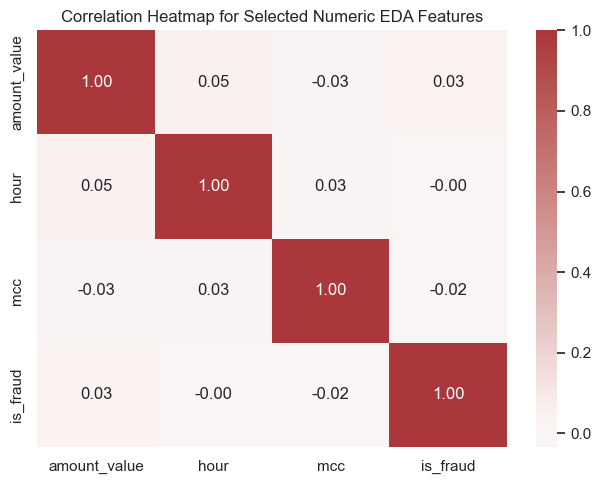

,amount_value,hour,mcc,is_fraud
amount_value,1.000,0.054,-0.033,0.032
hour,0.054,1.000,0.031,-0.003
mcc,-0.033,0.031,1.000,-0.015
is_fraud,0.032,-0.003,-0.015,1.000


In [ ]:

transactions["use_chip_code"] = transactions["use_chip"].map({"Chip Transaction": 0, "Swipe Transaction": 1, "Online Payment": 2}).fillna(-1)
transactions["has_error"] = transactions["errors"].notna().astype(int)

correlation_columns = ["amount_value", "use_chip_code", "hour", "mcc", "has_error", "is_fraud"]
corr = transactions[correlation_columns].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation Heatmap for Selected Numeric EDA Features")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_selected_feature_correlation.png", dpi=160, bbox_inches="tight")
plt.show()

corr.round(3)